# QAOA depth $p$ benchmark (cost & feasibility)

Fixed 4-node graph from `cost_landscape.ipynb`, tight penalties, CVaR $\alpha=0.25$ (except the XY mixer **no-aggregation** variant). Noise from `ibm_boston` via `NoiseModel.from_backend` and `AerSampler`, matching `generate_results.ipynb`.

**Cost curve:** conditional expectation of the normalized objective **given feasible** (same convention as `generate_results.ipynb`: `expected_value` on feasible samples after `feasibility_filter`).

In [1]:
import sys
import io
import contextlib
import warnings
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "max_k_cut").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer

from max_k_cut import (
    docplex_QUBO,
    docplex_RQUBO,
    docplex_QUBO_no_constraints,
    tight_qubo_penalty,
    tight_rqubo_penalty,
    create_dicke_initial_state,
    create_reduced_dicke_initial_state,
    create_ring_xy_mixer,
    feasibility_filter,
    expected_value,
)
from max_k_cut.qaoa import run_qaoa_extract_samples

warnings.filterwarnings("ignore", category=DeprecationWarning)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [2]:
# --- IBM Quantum: noise model from real backend (not fake backends) ---
# Uses saved account name; set to match your `qiskit-ibm-runtime` config.
SERVICE_NAME = "QCOL"  # QLSAs token is currently invalid; QCOL reaches the same ibm_boston backend
BACKEND_NAME = "ibm_boston"

try:
    service = QiskitRuntimeService(name=SERVICE_NAME)
    backend = service.backend(BACKEND_NAME)
except Exception as e:
    raise RuntimeError(
        f"Could not open QiskitRuntimeService({SERVICE_NAME!r}) or backend {BACKEND_NAME!r}. "
        "Configure IBM Quantum credentials / saved account first."
    ) from e

noise_model = NoiseModel.from_backend(backend)
print(f"Noise model from {backend.name} ({backend.num_qubits} qubits)")

Noise model from ibm_boston (156 qubits)


In [3]:
# --- Same graph as cost_landscape.ipynb ---
K = 3
M, w_spoke = 5, 1

G = nx.Graph()
G.add_edge(0, 1, weight=M)
G.add_edge(1, 2, weight=M)
G.add_edge(2, 0, weight=M)
G.add_edge(0, 3, weight=w_spoke)
G.add_edge(1, 3, weight=w_spoke)
G.add_edge(2, 3, weight=w_spoke)

num_nodes = G.number_of_nodes()
penalty_qubo = tight_qubo_penalty(G, K)
penalty_rqubo = tight_rqubo_penalty(G, K)

dp_qubo = docplex_QUBO(G, K, penalty_qubo, "QUBO_tight_p_sweep")
dp_rqubo = docplex_RQUBO(G, K, penalty_rqubo, "RQUBO_tight_p_sweep")
dp_xy = docplex_QUBO_no_constraints(G, K, "QUBO_xy_p_sweep")

print(f"nodes={num_nodes}, edges={G.number_of_edges()}, QUBO qubits={num_nodes * K}, RQUBO qubits={num_nodes * (K - 1)}")

nodes=4, edges=6, QUBO qubits=12, RQUBO qubits=8


In [4]:
# --- Experiment parameters (match generate_results experiment cell) ---
cvar_alpha = 0.25
shots = int(2500 / cvar_alpha)

optimizer = COBYLA()

sampler = AerSampler(
    backend_options=dict(noise_model=noise_model),
    run_options=dict(shots=shots),
)

P_LIST = np.arange(1, 6, dtype=int)  # tune: e.g. np.arange(1, 5)
SEED = 42

DATA_DIR = Path(_root) / "notebooks" / "experiments" / "Data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = DATA_DIR / "qaoa_p_sweep_ibm_boston.npz"
# Invalidate caches from runs that used unconditional E[f] over all samples
EXP_METRIC = "conditional_E_ratio_given_feasible"

print("cvar_alpha:", cvar_alpha, "shots:", shots, "P_LIST:", list(P_LIST))

cvar_alpha: 0.25 shots: 10000 P_LIST: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [5]:
# Model registry: internal key -> (docplex model, feasibility label, plot label)
MODELS = {
    "qubo": (dp_qubo, "QUBO (tight)", "QUBO"),
    "rqubo": (dp_rqubo, "RQUBO (tight)", "R-QUBO"),
    "dicke_qubo": (dp_qubo, "QUBO (Dicke init)", "Dicke QUBO"),
    "dicke_rqubo": (dp_rqubo, "RQUBO (Dicke init)", "Dicke R-QUBO"),
    "qubo_xy": (dp_xy, "QUBO (XY)", "QUBO + Mixer"),
    "qubo_xy_noagg": (dp_xy, "QUBO (XY) no-agg", "Mixer (no aggregation)"),
}

MODEL_ORDER = ["qubo", "rqubo", "dicke_qubo", "dicke_rqubo", "qubo_xy", "qubo_xy_noagg"]


def build_min_eigen_optimizer(
    *,
    reps: int,
    rng: np.random.Generator,
    use_aggregation: bool,
    variant: str,
):
    """Build MinimumEigenOptimizer(QAOA(...)) for one variant and depth `reps`."""
    initial_point = rng.random(2 * reps) * (np.pi / 2)

    if variant == "qubo" or variant == "rqubo":
        qaoa_kwargs = dict(
            sampler=sampler,
            optimizer=optimizer,
            reps=reps,
            initial_point=initial_point,
        )
        if use_aggregation:
            qaoa_kwargs["aggregation"] = float(cvar_alpha)
        return MinimumEigenOptimizer(QAOA(**qaoa_kwargs))

    if variant == "dicke_qubo":
        init_qc = create_dicke_initial_state(num_nodes, K)
        qaoa_kwargs = dict(
            sampler=sampler,
            optimizer=optimizer,
            reps=reps,
            initial_state=init_qc,
            initial_point=initial_point,
        )
        if use_aggregation:
            qaoa_kwargs["aggregation"] = float(cvar_alpha)
        return MinimumEigenOptimizer(QAOA(**qaoa_kwargs))

    if variant == "dicke_rqubo":
        init_qc = create_reduced_dicke_initial_state(num_nodes, K)
        qaoa_kwargs = dict(
            sampler=sampler,
            optimizer=optimizer,
            reps=reps,
            initial_state=init_qc,
            initial_point=initial_point,
        )
        if use_aggregation:
            qaoa_kwargs["aggregation"] = float(cvar_alpha)
        return MinimumEigenOptimizer(QAOA(**qaoa_kwargs))

    if variant in ("qubo_xy", "qubo_xy_noagg"):
        beta = Parameter("beta")
        init_qc = create_dicke_initial_state(num_nodes, K)
        mixer_qc = create_ring_xy_mixer(num_nodes, K, beta)
        qaoa_kwargs = dict(
            sampler=sampler,
            optimizer=optimizer,
            reps=reps,
            initial_state=init_qc,
            mixer=mixer_qc,
            initial_point=initial_point,
        )
        if variant == "qubo_xy":
            qaoa_kwargs["aggregation"] = float(cvar_alpha)
        return MinimumEigenOptimizer(QAOA(**qaoa_kwargs))

    raise ValueError(variant)


def run_one(dp_model, feas_label, variant: str, p: int, quiet: bool = True):
    """Return (E[normalized fval | feasible], P_feasible), matching generate_results.ipynb."""
    rng = np.random.default_rng(SEED + 1009 * p + sum(ord(c) for c in variant))
    use_agg = variant != "qubo_xy_noagg"
    opt = build_min_eigen_optimizer(
        reps=int(p),
        rng=rng,
        use_aggregation=use_agg,
        variant=variant,
    )
    ctx = contextlib.redirect_stdout(io.StringIO()) if quiet else contextlib.nullcontext()
    with ctx:
        out = run_qaoa_extract_samples([dp_model], [feas_label], opt)
        samples = out[feas_label]["samples"]
        feasible_samples, p_feas = feasibility_filter(G, K, samples, label=feas_label)
        if len(feasible_samples) == 0:
            exp_cond = np.nan
        else:
            exp_cond = float(expected_value(feasible_samples))
    return exp_cond, float(p_feas)

In [6]:
# --- Run sweep (loads cache when present) ---

exp_results = {k: np.full(len(P_LIST), np.nan) for k in MODEL_ORDER}
feas_results = {k: np.full(len(P_LIST), np.nan) for k in MODEL_ORDER}

if CACHE_PATH.is_file():
    cached = np.load(CACHE_PATH, allow_pickle=True)
    try:
        metric_ok = str(np.asarray(cached["exp_metric"]).reshape(-1)[0]) == EXP_METRIC
    except KeyError:
        metric_ok = False
    if (
        metric_ok
        and np.array_equal(cached["P_LIST"], P_LIST)
        and float(cached["cvar_alpha"]) == float(cvar_alpha)
        and int(cached["shots"]) == int(shots)
    ):
        for k in MODEL_ORDER:
            if f"exp_{k}" in cached:
                exp_results[k] = cached[f"exp_{k}"].astype(float)
                feas_results[k] = cached[f"feas_{k}"].astype(float)
        print("Loaded cached results from", CACHE_PATH)
    else:
        print("Cache mismatch (metric, P_LIST, alpha, or shots); re-running full sweep.")

for mi, key in enumerate(MODEL_ORDER):
    dp_model, feas_label, _ = MODELS[key]
    for pi, p in enumerate(P_LIST):
        if not np.isnan(exp_results[key][pi]):
            continue
        print(f"[{mi+1}/{len(MODEL_ORDER)}] {key}  p={p} ...")
        exp_v, p_feas = run_one(dp_model, feas_label, key, int(p), quiet=True)
        exp_results[key][pi] = exp_v
        feas_results[key][pi] = p_feas
        np.savez_compressed(
            CACHE_PATH,
            exp_metric=np.array(EXP_METRIC),
            P_LIST=P_LIST,
            cvar_alpha=cvar_alpha,
            shots=shots,
            SERVICE_NAME=np.array(SERVICE_NAME),
            BACKEND_NAME=np.array(BACKEND_NAME),
            **{f"exp_{k}": exp_results[k] for k in MODEL_ORDER},
            **{f"feas_{k}": feas_results[k] for k in MODEL_ORDER},
        )
        print(f"    E[ratio|feas]={exp_v:.4f}, P_feas={p_feas:.4f}")

print("Done.")

Loaded cached results from /Users/adrianharkness/Developer/lehigh/Max_K_Cut/notebooks/experiments/Data/qaoa_p_sweep_ibm_boston.npz
Done.


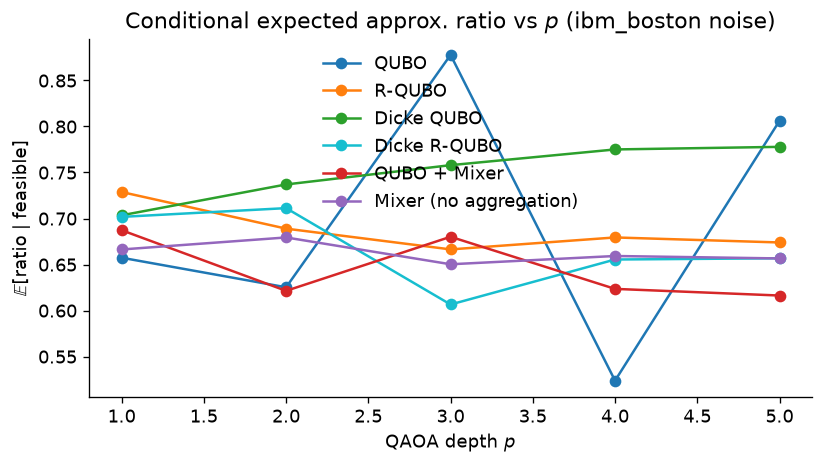

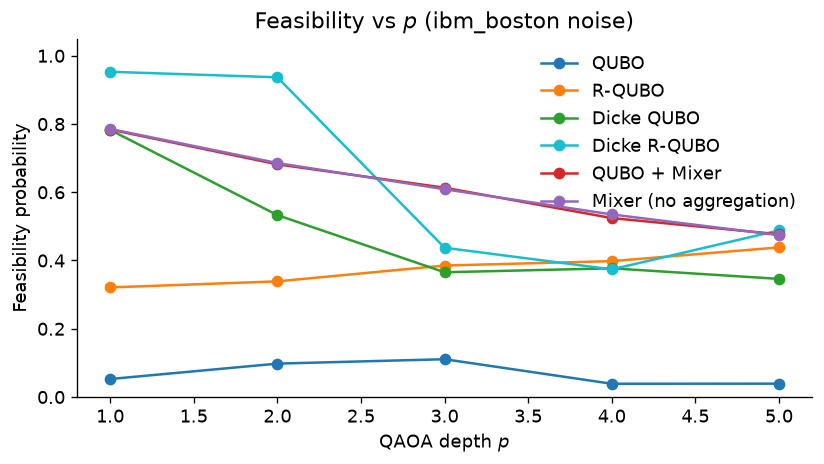

In [7]:
# --- Plots ---
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#17becf", "#d62728", "#9467bd"]

fig, ax = plt.subplots(figsize=(7, 4))
for color, key in zip(COLORS, MODEL_ORDER):
    _, _, leg = MODELS[key]
    ax.plot(P_LIST, exp_results[key], marker="o", label=leg, color=color)
ax.set_xlabel(r"QAOA depth $p$")
ax.set_ylabel(r"$\mathbb{E}[\mathrm{ratio} \mid \mathrm{feasible}]$")
ax.set_title("Conditional expected approx. ratio vs $p$ (ibm_boston noise)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(DATA_DIR / "qaoa_p_sweep_expected_cost.pdf")
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 4))
for color, key in zip(COLORS, MODEL_ORDER):
    _, _, leg = MODELS[key]
    ax2.plot(P_LIST, feas_results[key], marker="o", label=leg, color=color)
ax2.set_xlabel(r"QAOA depth $p$")
ax2.set_ylabel(r"Feasibility probability")
ax2.set_title("Feasibility vs $p$ (ibm_boston noise)")
ax2.set_ylim(0.0, 1.05)
ax2.legend(frameon=False)
fig2.tight_layout()
fig2.savefig(DATA_DIR / "qaoa_p_sweep_feasibility.pdf")
plt.show()